In [1]:
import torch
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)


Using device: mps


In [2]:
import torch.nn as nn

class ControlledVanDerPolNODEFunc(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)
        )

    def forward(self, x, u):
        xu = torch.cat([x, u], dim=1)
        dxdt = self.net(xu)
        return dxdt

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

checkpoint = torch.load(
    "/Users/hotrongtai/Downloads/Pre_learning/NODE/controlled_vdp_node_best.pt",
    map_location=device
)

node_model = ControlledVanDerPolNODEFunc().to(device)
node_model.load_state_dict(checkpoint["model_state_dict"])

node_model.eval()

for p in node_model.parameters():
    p.requires_grad_(False)

mu = float(checkpoint["mu"])
b = float(checkpoint["b"])
dt = float(checkpoint["dt"])


print("Loaded NODE model.")
print("Checkpoint info:")
print("mu:", checkpoint["mu"])
print("b:", checkpoint["b"])
print("dt:", checkpoint["dt"])
print("T:", checkpoint["T"])
print("n_steps:", checkpoint["n_steps"])

Loaded NODE model.
Checkpoint info:
mu: 1.0
b: 1.0
dt: 0.07537688314914703
T: 15.0
n_steps: 200


In [ ]:
def true_controlled_vdp_dynamics(x, u, mu=1.0, b=1.0):
    """
    Controlled Van der Pol:

        dx1/dt = x2
        dx2/dt = mu*(1 - x1^2)*x2 - x1 + b*u

    x shape: [batch_size, 2]
    u shape: [batch_size, 1]
    """

    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    dx1dt = x2
    dx2dt = mu * (1.0 - x1**2) * x2 - x1 + b * u

    return torch.cat([dx1dt, dx2dt], dim=1)

# Simulate the true dynamics using RK4 for better accuracy in the MPC loop
def rk4_step_true_controlled_vdp(x, u, dt, mu=1.0, b=1.0):
    """
    RK4 step for the true controlled Van der Pol dynamics.
    """

    k1 = true_controlled_vdp_dynamics(x, u, mu, b)
    k2 = true_controlled_vdp_dynamics(x + 0.5 * dt * k1, u, mu, b)
    k3 = true_controlled_vdp_dynamics(x + 0.5 * dt * k2, u, mu, b)
    k4 = true_controlled_vdp_dynamics(x + dt * k3, u, mu, b)

    x_next = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x_next

In [ ]:
#Linearization of the continouos-model dynamics_func before put into MPC optimization loop
def rk4_step(dynamics_func, x, u, dt):
    k1 = dynamics_func(x, u)
    k2 = dynamics_func(x + 0.5 * dt * k1, u)
    k3 = dynamics_func(x + 0.5 * dt * k2, u)
    k4 = dynamics_func(x + dt * k3, u)

    x_next = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x_next


In [6]:
def rollout_dynamics(dynamics_func, x0, u_seq, dt):
    
    states = [x0.squeeze(0)]
    x = x0

    for k in range(u_seq.shape[0]):
        u_k = u_seq[k:k+1, :]   # shape [1, 1]

        x = rk4_step(
            dynamics_func=dynamics_func,
            x=x,
            u=u_k,
            dt=dt
        )

        states.append(x.squeeze(0))

    return torch.stack(states, dim=0)


In [7]:
def mpc_cost(states, u_seq, x_ref, u_ref, q, r, qf):
    """
    states shape: [Np + 1, 2]
    u_seq shape: [Np, 1]
    x_ref shape: [2]
    u_ref shape: [1]
    """

    # Tracking state error
    err = states[:-1] - x_ref
    state_cost = torch.sum(q * err**2)

    # Penalize input deviation from u_ref
    input_err = u_seq - u_ref
    input_cost = r * torch.sum(input_err**2)

    # Terminal cost
    terminal_err = states[-1] - x_ref
    terminal_cost = torch.sum(qf * terminal_err**2)

    return state_cost + input_cost + terminal_cost

In [8]:
def solve_mpc(
    prediction_func,
    x_current,
    x_ref,
    u_ref,
    Np=20,
    dt=0.075,
    num_iters=100,
    lr=0.03,
    u_max=1.0
):

    q = torch.tensor([10.0, 1.0], device=device)
    qf = torch.tensor([30.0, 5.0], device=device)
    r = torch.tensor(0.1, device=device)

    ratio = (u_ref / u_max).clamp(-0.95, 0.95)
    raw_init = torch.atanh(ratio).repeat(Np, 1).detach()
    raw_u = raw_init.clone().to(device).requires_grad_(True)
    
    optimizer = torch.optim.Adam([raw_u], lr=lr)

    cost_history = []

    for _ in range(num_iters):
        optimizer.zero_grad()

        u_seq = u_max * torch.tanh(raw_u)

        states = rollout_dynamics(
            dynamics_func=prediction_func,
            x0=x_current,
            u_seq=u_seq,
            dt=dt
        )

        cost = mpc_cost(
            states=states,
            u_seq=u_seq,
            x_ref=x_ref,
            u_ref=u_ref,
            q=q,
            r=r,
            qf=qf
        )

        cost.backward()
        optimizer.step()

        cost_history.append(cost.item())

    with torch.no_grad():
        u_opt = u_max * torch.tanh(raw_u)

        states_opt = rollout_dynamics(
            dynamics_func=prediction_func,
            x0=x_current,
            u_seq=u_opt,
            dt=dt
        )

    return u_opt.detach(), states_opt.detach(), cost_history



In [9]:
def simulate_closed_loop_mpc(
    prediction_func,
    plant_func,
    x_init,
    x_ref,
    u_ref,
    sim_steps=100,
    Np=20,
    dt=0.05,
    u_max=1.0,
    num_iters=100,
    lr=0.03
):
    """
    Closed-loop MPC .

    prediction_func:
        model insize MPC use to predict

    plant_func:
        true system use to update state after applying u0
    """

    x = x_init.clone().to(device)

    x_history = [x.squeeze(0).detach().cpu()]
    u_history = []

    for step in range(sim_steps):
        u_opt, _, _ = solve_mpc(
            prediction_func=prediction_func,
            x_current=x,
            x_ref=x_ref,
            u_ref=u_ref,
            Np=Np,
            dt=dt,
            u_max=u_max,
            num_iters=num_iters,
            lr=lr
        )

        u0 = u_opt[0:1, :]  # [1, 1]

        # Apply u0 to the true system
        x = rk4_step(
            dynamics_func=plant_func,
            x=x,
            u=u0,
            dt=dt
        )

        x_history.append(x.squeeze(0).detach().cpu())
        u_history.append(u0.squeeze(0).detach().cpu())

        if step % 10 == 0:
            print(
                f"Step {step:3d} | "
                f"x = {x.squeeze(0).detach().cpu().numpy()} | "
                f"u = {u0.item():.4f}"
            )

    x_history = torch.stack(x_history, dim=0)
    u_history = torch.stack(u_history, dim=0)

    return x_history, u_history

In [10]:
x_init = torch.tensor([[2.0, 0.0]], device=device)
x_ref = torch.tensor([0.5, 0.0], device=device)
u_ref = torch.tensor([x_ref[0].item() / b], device=device)


In [11]:
true_func = lambda x, u: true_controlled_vdp_dynamics(
    x=x,
    u=u,
    mu=mu,
    b=b
)

node_func = lambda x, u: node_model(x, u)

In [12]:
x_hist_node, u_hist_node = simulate_closed_loop_mpc(
    prediction_func=node_func,   
    plant_func=true_func,        
    x_init=x_init,
    x_ref=x_ref,
    u_ref=u_ref,
    sim_steps=200,
    Np=20,
    dt=dt,
    u_max=1.0,
    num_iters=100,
    lr=0.1
)

Step   0 | x = [ 1.9921154  -0.20155655] | u = -0.9889
Step  10 | x = [ 1.442428 -0.949836] | u = 0.9759
Step  20 | x = [ 0.7919174  -0.85528547] | u = 0.9967
Step  30 | x = [ 0.10219435 -0.97105384] | u = 0.9974
Step  40 | x = [-0.56171703 -0.6354515 ] | u = 0.9964
Step  50 | x = [-0.6198878   0.57896936] | u = 0.9723
Step  60 | x = [0.02109335 0.88894194] | u = -0.9949
Step  70 | x = [0.557089   0.38605267] | u = -0.9607
Step  80 | x = [ 0.51915115 -0.24367899] | u = 0.7270
Step  90 | x = [ 0.37053916 -0.12618575] | u = 0.7381
Step 100 | x = [0.33653557 0.00185396] | u = 0.3867
Step 110 | x = [0.3466039  0.01736674] | u = 0.3221
Step 120 | x = [ 3.5336384e-01 -3.3741945e-04] | u = 0.3327
Step 130 | x = [ 0.35075578 -0.00395283] | u = 0.3570
Step 140 | x = [ 0.3487968  -0.00122345] | u = 0.3533
Step 150 | x = [3.4854558e-01 2.4271553e-04] | u = 0.3492
Step 160 | x = [3.4878892e-01 2.6882099e-04] | u = 0.3482
Step 170 | x = [3.4889093e-01 2.2025195e-05] | u = 0.3486
Step 180 | x = [ 3.

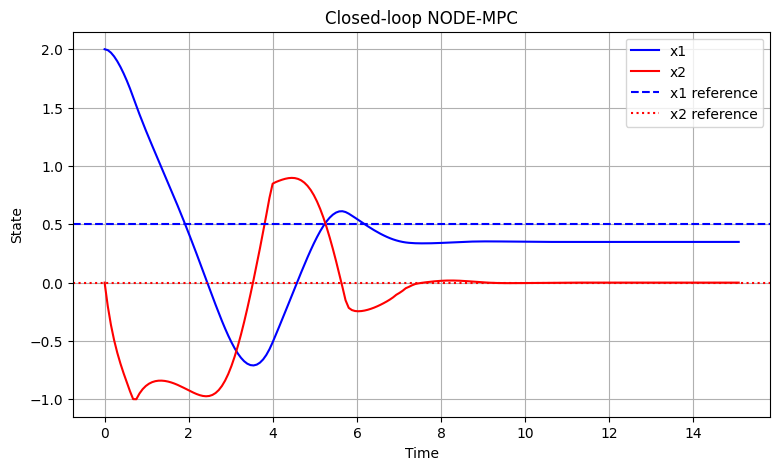

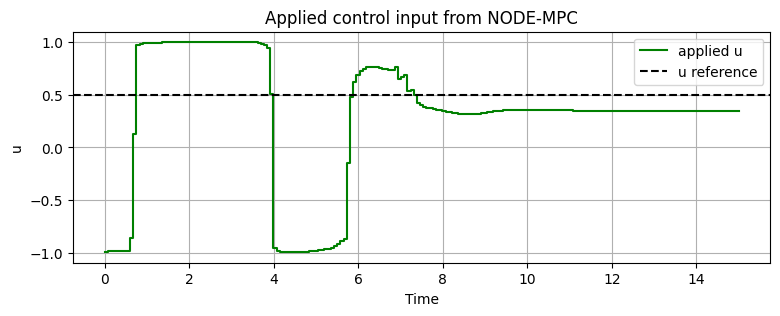

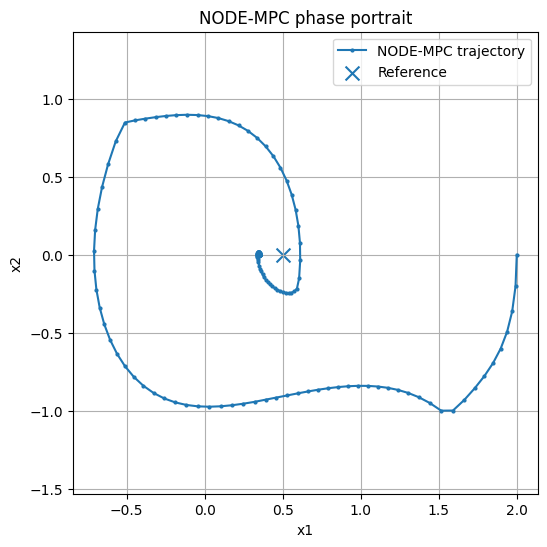

In [13]:
x_ref_cpu = x_ref.detach().cpu()
u_ref_cpu = u_ref.detach().cpu()

t_sim = torch.arange(x_hist_node.shape[0]) * dt
t_u = torch.arange(u_hist_node.shape[0]) * dt

plt.figure(figsize=(9, 5))
plt.plot(t_sim.numpy(), x_hist_node[:, 0].numpy(), label="x1", color="blue")
plt.plot(t_sim.numpy(), x_hist_node[:, 1].numpy(), label="x2", color="red")

plt.axhline(x_ref_cpu[0].item(), linestyle="--", label="x1 reference", color="blue")
plt.axhline(x_ref_cpu[1].item(), linestyle=":", label="x2 reference", color="red")

plt.xlabel("Time")
plt.ylabel("State")
plt.title("Closed-loop NODE-MPC")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 3))
plt.step(t_u.numpy(), u_hist_node[:, 0].numpy(), where="post", label="applied u", color="green")
plt.axhline(u_ref_cpu[0].item(), linestyle="--", label="u reference", color="black")
plt.xlabel("Time")
plt.ylabel("u")
plt.title("Applied control input from NODE-MPC")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(
    x_hist_node[:, 0].numpy(),
    x_hist_node[:, 1].numpy(),
    marker="o",
    markersize=2,
    label="NODE-MPC trajectory"
)

plt.scatter(
    [x_ref_cpu[0].item()],
    [x_ref_cpu[1].item()],
    marker="x",
    s=100,
    label="Reference"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("NODE-MPC phase portrait")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()